# Single Asset Backtest with VectorBT

**Docker image**: `ml4t`

This notebook introduces **VectorBT**, a vectorized backtesting library that enables
fast simulation of trading strategies. We start with a simple single-asset RSI mean-reversion
strategy on Bitcoin before moving to multi-asset portfolio strategies. Every performance result
is an in-sample teaching output, not a holdout estimate or deployable strategy claim.

**Learning Objectives:**

1. Understand VectorBT's core API and portfolio simulation
2. Implement entry/exit signals from technical indicators
3. Analyze performance metrics and visualizations
4. Compare strategy vs buy-and-hold benchmark

**Book Reference:** Chapter 16, Section 16.3 - vectorized and event-driven engines.

**Prerequisites:** Ch16 NB 01 (backtesting first principles).

**Strategy:** RSI Mean Reversion on BTC

- **Long Entry**: RSI below the configured lower threshold
- **Exit**: RSI above the configured upper threshold
- **Rebalancing**: Daily
- **Transaction Costs**: Fee plus slippage on each fill

## Setup

In [1]:
"""Single-asset RSI mean-reversion strategy using vectorized backtesting."""

import plotly.graph_objects as go
import polars as pl
import vectorbt as vbt
from IPython.display import Markdown, display
from ml4t.diagnostic.evaluation import PortfolioAnalysis
from plotly.subplots import make_subplots

from data import load_crypto_perps
from utils.style import COLORS, ml4t_diverging, show_plotly_with_alt

In [2]:
# Production defaults - Papermill injects overrides for CI
START_DATE = "2020-01-01"
END_DATE = "2024-01-01"
INITIAL_CASH = 100_000
RSI_WINDOW = 14
RSI_LOWER = 30
RSI_UPPER = 70
SIZE_FRACTION = 0.95
FEES = 0.001
SLIPPAGE = 0.0005

In [3]:
display(
    Markdown(
        f"The configured rule uses a **{RSI_WINDOW}-day RSI**, enters below **{RSI_LOWER}**, "
        f"exits above **{RSI_UPPER}**, and allocates **{SIZE_FRACTION:.0%}** of available capital. "
        f"Each fill pays a **{FEES:.2%} fee** plus **{SLIPPAGE:.2%} slippage**."
    )
)

The configured rule uses a **14-day RSI**, enters below **30**, exits above **70**, and allocates **95%** of available capital. Each fill pays a **0.10% fee** plus **0.05% slippage**.

## 1. Data Acquisition

Load BTC/USDT daily bars from the local crypto perpetuals dataset and
convert to pandas Series indexed by timestamp at the VectorBT boundary. The UTC-day aggregation
is a calendar convention for a continuously traded market, not an exchange session close.

In [4]:
_crypto = load_crypto_perps(
    symbols=["BTCUSDT"],
    start_date=START_DATE,
    end_date=END_DATE,
)
btc_df = (
    _crypto.filter(
        (pl.col("symbol") == "BTCUSDT")
        & (pl.col("timestamp") >= pl.lit(START_DATE).str.to_datetime().dt.replace_time_zone("UTC"))
        & (pl.col("timestamp") < pl.lit(END_DATE).str.to_datetime().dt.replace_time_zone("UTC"))
    )
    .sort("timestamp")
    .with_columns(pl.col("timestamp").dt.replace_time_zone(None))
    .group_by_dynamic("timestamp", every="1d", group_by="symbol")
    .agg(
        pl.col("open").first(),
        pl.col("high").max(),
        pl.col("low").min(),
        pl.col("close").last(),
        pl.col("volume").sum(),
    )
    .sort(["symbol", "timestamp"])
)

Canonical keys must remain unique through aggregation. Positive, internally consistent OHLC bars
protect the backtest from malformed price records before the VectorBT boundary.

In [5]:
assert btc_df.n_unique(["symbol", "timestamp"]) == len(btc_df)
assert btc_df["symbol"].unique().to_list() == ["BTCUSDT"]
price_columns = ["open", "high", "low", "close"]
assert btc_df.select(pl.col(price_columns).is_not_null().all()).row(0) == (True,) * 4
assert btc_df.select((pl.col(price_columns) > 0).all()).row(0) == (True,) * 4
assert btc_df.select((pl.col("high") >= pl.max_horizontal("open", "close", "low")).all()).item()
assert btc_df.select((pl.col("low") <= pl.min_horizontal("open", "close", "high")).all()).item()
assert len(btc_df) > RSI_WINDOW

# Convert at the library boundary; subsequent pandas objects come from VectorBT.
btc_pd = btc_df.to_pandas()
btc_pd.set_index("timestamp", inplace=True)
close = btc_pd["close"]
execution_price = btc_pd["open"]

print(f"Loaded {len(btc_df):,} daily bars for BTCUSDT from the crypto perpetuals dataset")
print(f"Date range: {btc_df['timestamp'].min()} to {btc_df['timestamp'].max()}")

Loaded 1,461 daily bars for BTCUSDT from the crypto perpetuals dataset
Date range: 2020-01-01 00:00:00 to 2023-12-31 00:00:00


In [6]:
close.head(10)

timestamp
2020-01-01    7197.57
2020-01-02    6962.04
2020-01-03    7341.72
2020-01-04    7350.71
2020-01-05    7354.36
2020-01-06    7757.39
2020-01-07    8152.49
2020-01-08    8059.84
2020-01-09    7818.59
2020-01-10    8207.09
Name: close, dtype: float64

## 2. RSI Indicator Calculation

VectorBT provides optimized indicator calculations. The RSI indicator
can be computed for multiple parameter values simultaneously.

In [7]:
rsi = vbt.RSI.run(close, window=RSI_WINDOW)

In [8]:
rsi_series = rsi.rsi

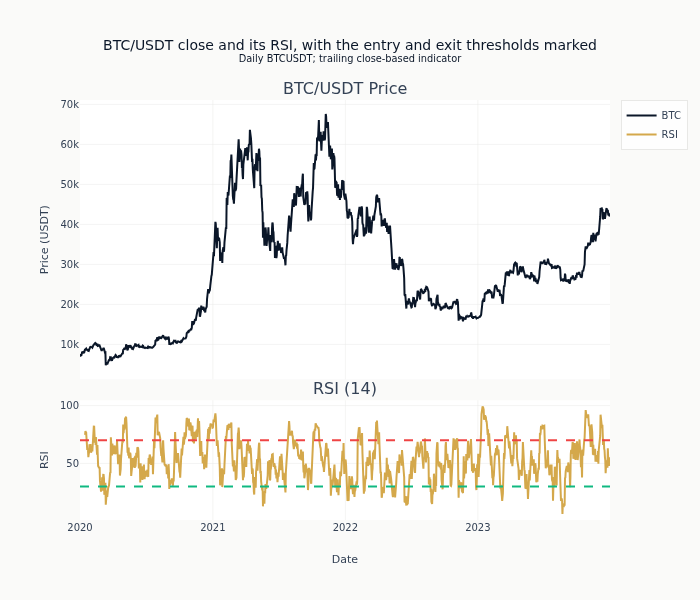

In [9]:
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    row_heights=[0.7, 0.3],
    subplot_titles=["BTC/USDT Price", f"RSI ({RSI_WINDOW})"],
)

fig.add_trace(
    go.Scatter(x=close.index, y=close, name="BTC", line=dict(color=COLORS["blue"])),
    row=1,
    col=1,
)

fig.add_trace(
    go.Scatter(x=rsi_series.index, y=rsi_series, name="RSI", line=dict(color=COLORS["amber"])),
    row=2,
    col=1,
)

fig.add_hline(y=RSI_LOWER, line_dash="dash", line_color=COLORS["positive"], row=2, col=1)
fig.add_hline(y=RSI_UPPER, line_dash="dash", line_color=COLORS["negative"], row=2, col=1)

fig.update_layout(
    height=600,
    title=(
        "BTC/USDT close and its RSI, with the entry and exit thresholds marked"
        "<br><sup>Daily BTCUSDT; trailing close-based indicator</sup>"
    ),
    showlegend=True,
    xaxis2_title="Date",
    yaxis_title="Price (USDT)",
    yaxis2_title="RSI",
)
show_plotly_with_alt(
    fig,
    (
        "Two stacked panels on a shared date axis. The upper panel is the BTC/USDT daily "
        f"close in USDT. The lower panel is the {RSI_WINDOW}-period RSI computed from those "
        "same closes, in amber, with dashed horizontal lines at the entry and exit "
        "thresholds. Stacked on one date axis so the indicator and the thresholds that act on "
        "it can be read against the price history they are derived from."
    ),
)

## 3. Generate Trading Signals

RSI Mean Reversion Logic:

- **Enter Long**: the prior close's RSI is below the lower threshold
- **Exit Long**: the prior close's RSI is above the upper threshold

RSI is observed only after the daily close. Shifting both conditions by one row makes the order
eligible at the next UTC day's open and prevents a same-close look-ahead fill.

In [10]:
entry_condition = rsi_series < RSI_LOWER
exit_condition = rsi_series > RSI_UPPER
entries = entry_condition.shift(1, fill_value=False)
exits = exit_condition.shift(1, fill_value=False)

In [11]:
entry_days = int(entries.sum())
exit_days = int(exits.sum())
display(
    Markdown(
        f"The conditions mark **{entry_days} entry-eligible days** and "
        f"**{exit_days} exit-eligible days**. Repeated signals while a position is already "
        "open do not create additional trades."
    )
)

The conditions mark **146 entry-eligible days** and **265 exit-eligible days**. Repeated signals while a position is already open do not create additional trades.

## 4. Run Backtest with VectorBT

VectorBT's `Portfolio.from_signals()` is the core backtesting function.
It simulates a portfolio based on entry/exit signals.

In [12]:
portfolio = vbt.Portfolio.from_signals(
    close=close,
    entries=entries,
    exits=exits,
    price=execution_price,
    open=execution_price,
    size=SIZE_FRACTION,
    size_type="percent",
    init_cash=INITIAL_CASH,
    fees=FEES,
    slippage=SLIPPAGE,
    freq="1D",
)

**Portfolio performance summary** (VectorBT's built-in strategy statistics):

The matched-cost benchmark is constructed below. This view suppresses VectorBT's implicit
frictionless close-to-close benchmark so the notebook does not mix execution assumptions.

In [13]:
strategy_stats = portfolio.stats()
strategy_stats.drop(labels=["Benchmark Return [%]"], errors="ignore")

Start                         2020-01-01 00:00:00
End                           2023-12-31 00:00:00
Period                         1461 days 00:00:00
Start Value                              100000.0
End Value                             74606.13062
Total Return [%]                       -25.393869
Max Gross Exposure [%]                  96.079653
Total Fees Paid                        2038.63821
Max Drawdown [%]                        65.834276
Max Drawdown Duration           967 days 00:00:00
Total Trades                                   14
Total Closed Trades                            14
Total Open Trades                               0
Open Trade PnL                                0.0
Win Rate [%]                            57.142857
Best Trade [%]                          28.824535
Worst Trade [%]                        -43.724684
Avg Winning Trade [%]                   15.627826
Avg Losing Trade [%]                   -20.529787
Avg Winning Trade Duration       22 days 00:00:00


In [14]:
baseline_return = float(portfolio.total_return())
baseline_sharpe = float(portfolio.sharpe_ratio())
display(
    Markdown(
        f"The configured RSI rule returns **{baseline_return:.2%}** with a "
        f"**{baseline_sharpe:.2f} Sharpe ratio** in this sample. This descriptive output shows "
        "what the rule did, but does not identify a persistent mean-reversion premium or estimate "
        "out-of-sample performance."
    )
)

The configured RSI rule returns **-25.39%** with a **0.09 Sharpe ratio** in this sample. This descriptive output shows what the rule did, but does not identify a persistent mean-reversion premium or estimate out-of-sample performance.

## 5. Analyze Trade Statistics

VectorBT records each trade lifecycle, including any position still open at the sample end. The
table exposes entry and exit prices so the execution convention remains auditable.

In [15]:
trades = portfolio.trades.records_readable
display(Markdown(f"The simulation contains **{len(trades)} trade records**."))

The simulation contains **14 trade records**.

**Trade statistics** (per-trade entry/exit, P&L, holding period summary):

In [16]:
portfolio.trades.stats()

Start                         2020-01-01 00:00:00
End                           2023-12-31 00:00:00
Period                         1461 days 00:00:00
First Trade Start             2020-02-27 00:00:00
Last Trade End                2023-10-09 00:00:00
Coverage                        629 days 00:00:00
Overlap Coverage                  0 days 00:00:00
Total Records                                  14
Total Long Trades                              14
Total Short Trades                              0
Total Closed Trades                            14
Total Open Trades                               0
Open Trade PnL                                0.0
Win Rate [%]                            57.142857
Max Win Streak                                  4
Max Loss Streak                                 2
Best Trade [%]                          28.824535
Worst Trade [%]                        -43.724684
Avg Winning Trade [%]                   15.627826
Avg Losing Trade [%]                   -20.529787


**Sample individual trades** with entry/exit timing and realized P&L:

In [17]:
display_cols = [
    "Entry Timestamp",
    "Exit Timestamp",
    "Size",
    "Entry Price",
    "Exit Price",
    "PnL",
    "Return",
]
available_cols = [c for c in display_cols if c in trades.columns]
trades[available_cols].head(10)

,Entry Timestamp,Exit Timestamp,Size,PnL,Return
0,2020-02-27,2020-03-27,10.786684,-22473.976033,-0.236805
1,2020-09-04,2020-09-20,7.251403,6526.107144,0.088699
2,2021-01-28,2021-02-07,2.624165,22993.260592,0.288245
3,2021-04-25,2021-07-28,2.026994,-21852.061955,-0.215097
4,2021-09-21,2021-10-06,1.878196,15573.782817,0.192619
5,2021-11-23,2022-02-05,1.698742,-25251.873249,-0.264049
6,2022-02-22,2022-03-26,1.936712,13910.021482,0.194090
7,2022-04-11,2022-08-09,2.012959,-37108.758709,-0.437247
8,2022-08-25,2022-10-27,2.323869,-1533.219678,-0.030880
9,2022-11-10,2022-12-14,3.028723,5517.054209,0.114471


## 6. Performance Visualization

Portfolio value reveals when the rule is invested and when capital is idle. The underwater curve
measures each close relative to the running peak, with zero fixed at the top of the chart.

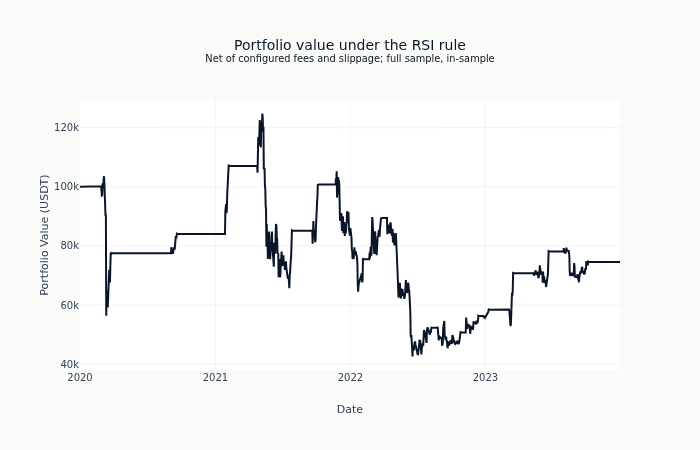

In [18]:
portfolio_value = portfolio.value()
fig = go.Figure(
    go.Scatter(
        x=portfolio_value.index,
        y=portfolio_value,
        name="Portfolio value",
        line=dict(color=COLORS["blue"]),
    )
)
fig.update_layout(
    title=(
        "Portfolio value under the RSI rule"
        "<br><sup>Net of configured fees and slippage; full sample, in-sample</sup>"
    ),
    xaxis_title="Date",
    yaxis_title="Portfolio Value (USDT)",
    height=450,
    hovermode="x unified",
)
show_plotly_with_alt(
    fig,
    (
        "Line chart of the RSI rule's portfolio value in USDT over the sample, starting from "
        "the configured initial cash. The rule is in the market only between an entry and its "
        "exit, so the series is flat wherever it holds no position and moves only on the "
        "sessions it is invested. Drawn to show the shape of a rule that trades "
        "intermittently rather than holding continuously."
    ),
)

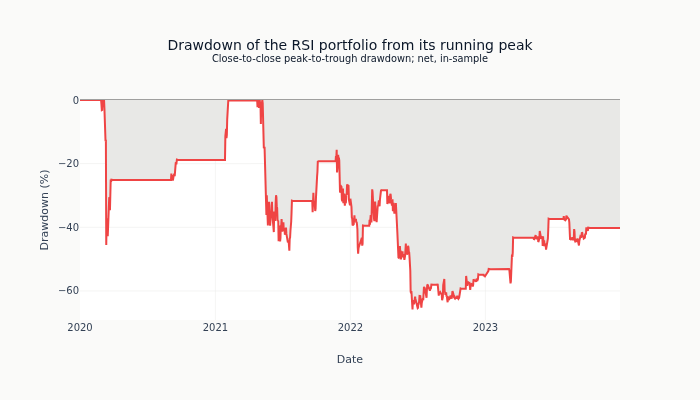

In [19]:
portfolio_drawdown = portfolio.drawdown() * 100
drawdown_floor = min(float(portfolio_drawdown.min()) * 1.05, -1.0)
fig_dd = go.Figure(
    go.Scatter(
        x=portfolio_drawdown.index,
        y=portfolio_drawdown,
        name="Drawdown",
        line=dict(color=COLORS["negative"]),
        fill="tozeroy",
        fillcolor=COLORS["silver_muted"],
    )
)
fig_dd.update_layout(
    title=(
        "Drawdown of the RSI portfolio from its running peak"
        "<br><sup>Close-to-close peak-to-trough drawdown; net, in-sample</sup>"
    ),
    xaxis_title="Date",
    yaxis_title="Drawdown (%)",
    yaxis_range=[drawdown_floor, 0],
    height=400,
    hovermode="x unified",
)
show_plotly_with_alt(
    fig_dd,
    (
        "Filled drawdown chart of the RSI portfolio measured from its own running peak, zero "
        "at the top and losses below, in percent. Each point is the distance from the highest "
        "portfolio value reached up to that date, so the series returns to zero only on a new "
        "high. Drawn beside the equity curve above because the same path answers a different "
        "question when it is measured against its own maximum."
    ),
)

## 7. Compare to Buy-and-Hold Benchmark

Buy-and-hold is a simple exposure benchmark. Both paths deploy the same fraction of capital and
use the same next-open price, fee, and slippage assumptions. The benchmark remains open at the
sample end, so it does not pay a terminal exit cost.

In [20]:
bh_portfolio = vbt.Portfolio.from_holding(
    close=close,
    price=execution_price,
    open=execution_price,
    size=SIZE_FRACTION,
    size_type="percent",
    init_cash=INITIAL_CASH,
    fees=FEES,
    slippage=SLIPPAGE,
    freq="1D",
)

In [21]:
comparison = pl.DataFrame(
    {
        "metric": [
            "Total Return (%)",
            "Sharpe Ratio",
            "Max Drawdown (%)",
            "Total Trades",
            "Sortino Ratio",
            "Calmar Ratio",
        ],
        "RSI Strategy": [
            float(portfolio.total_return() * 100),
            float(portfolio.sharpe_ratio()),
            float(portfolio.max_drawdown() * 100),
            float(portfolio.trades.count()),
            float(portfolio.sortino_ratio()),
            float(portfolio.calmar_ratio()),
        ],
        "Buy & Hold": [
            float(bh_portfolio.total_return() * 100),
            float(bh_portfolio.sharpe_ratio()),
            float(bh_portfolio.max_drawdown() * 100),
            float(bh_portfolio.trades.count()),
            float(bh_portfolio.sortino_ratio()),
            float(bh_portfolio.calmar_ratio()),
        ],
    }
)

**Strategy vs buy-and-hold comparison** (daily data; risk ratios use daily annualization):

In [22]:
comparison.with_columns(pl.col(["RSI Strategy", "Buy & Hold"]).round(3))

metric,RSI Strategy,Buy & Hold
str,f64,f64
"""Total Return (%)""",-25.394,463.293
"""Sharpe Ratio""",0.09,0.991
"""Max Drawdown (%)""",-65.834,-76.242
"""Total Trades""",14.0,1.0
"""Sortino Ratio""",0.121,1.432
"""Calmar Ratio""",-0.107,0.708


In [23]:
benchmark_return = float(bh_portfolio.total_return())
benchmark_sharpe = float(bh_portfolio.sharpe_ratio())
strategy_drawdown = float(portfolio.max_drawdown())
benchmark_drawdown = float(bh_portfolio.max_drawdown())
return_leader = "Buy-and-hold" if benchmark_return > baseline_return else "The RSI strategy"
display(
    Markdown(
        f"**{return_leader}** leads total return in this sample: "
        f"**{benchmark_return:.2%}** for buy-and-hold versus **{baseline_return:.2%}** for RSI. "
        f"Their Sharpe ratios are **{benchmark_sharpe:.2f}** and **{baseline_sharpe:.2f}**; maximum "
        f"drawdowns are **{benchmark_drawdown:.2%}** and **{strategy_drawdown:.2%}**, respectively. "
        "This is an in-sample exposure comparison, not evidence that either rule will dominate "
        "out of sample."
    )
)

**Buy-and-hold** leads total return in this sample: **463.29%** for buy-and-hold versus **-25.39%** for RSI. Their Sharpe ratios are **0.99** and **0.09**; maximum drawdowns are **-76.24%** and **-65.83%**, respectively. This is an in-sample exposure comparison, not evidence that either rule will dominate out of sample.

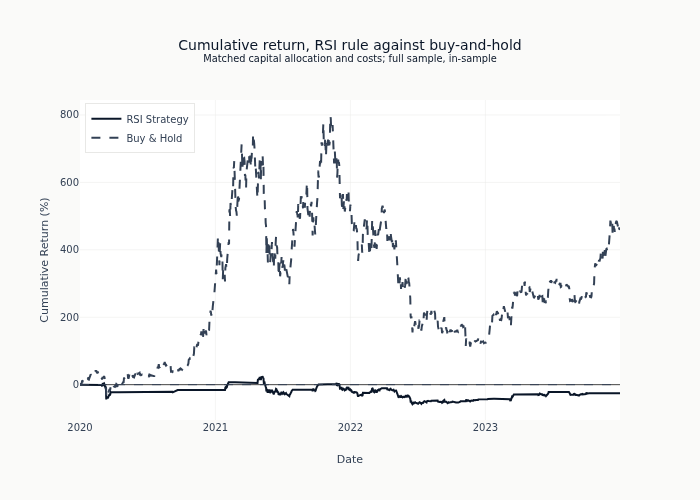

In [24]:
fig = go.Figure()

strategy_cum = portfolio.cumulative_returns() * 100
bh_cum = bh_portfolio.cumulative_returns() * 100

fig.add_trace(
    go.Scatter(
        x=strategy_cum.index,
        y=strategy_cum,
        name="RSI Strategy",
        line=dict(color=COLORS["blue"]),
    )
)

fig.add_trace(
    go.Scatter(
        x=bh_cum.index,
        y=bh_cum,
        name="Buy & Hold",
        line=dict(color=COLORS["neutral"], dash="dash"),
    )
)

fig.update_layout(
    title=(
        "Cumulative return, RSI rule against buy-and-hold"
        "<br><sup>Matched capital allocation and costs; full sample, in-sample</sup>"
    ),
    xaxis_title="Date",
    yaxis_title="Cumulative Return (%)",
    height=500,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
    hovermode="x unified",
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], line_width=1)
show_plotly_with_alt(
    fig,
    (
        "Cumulative return in percent for the RSI rule in solid navy and buy-and-hold in "
        "dashed grey, on one linear axis. Both are run on the same bars, from the same "
        "capital, and net of the same fees and slippage, so the only difference between them "
        "is when each is in the market. Drawn on a shared axis, which is what makes the two "
        "directly comparable and also what compresses the smaller of them."
    ),
)

## 8. Parameter Sensitivity

VectorBT makes parameter sweeps inexpensive. This section measures in-sample sensitivity; it does
not treat its highest-Sharpe row as a deployment choice, because no holdout is used.

In [25]:
rsi_windows = [7, 14, 21]
lower_thresholds = [20, 25, 30, 35]
upper_thresholds = [65, 70, 75, 80]

In [26]:
results = []

for window in rsi_windows:
    rsi_vals = vbt.RSI.run(close, window=window).rsi

    for lower in lower_thresholds:
        for upper in upper_thresholds:
            if lower >= upper:
                continue

            entries = (rsi_vals < lower).shift(1, fill_value=False)
            exits = (rsi_vals > upper).shift(1, fill_value=False)

            pf = vbt.Portfolio.from_signals(
                close=close,
                entries=entries,
                exits=exits,
                price=execution_price,
                open=execution_price,
                size=SIZE_FRACTION,
                size_type="percent",
                init_cash=INITIAL_CASH,
                fees=FEES,
                slippage=SLIPPAGE,
                freq="1D",
            )

            results.append(
                {
                    "window": window,
                    "lower": lower,
                    "upper": upper,
                    "total_return": pf.total_return() * 100,
                    "sharpe": pf.sharpe_ratio(),
                    "max_dd": pf.max_drawdown() * 100,
                    "trades": pf.trades.count(),
                }
            )

In [27]:
results_df = pl.DataFrame(results)
ranked_results = results_df.filter(pl.col("sharpe").is_finite()).sort("sharpe", descending=True)
assert len(ranked_results) > 0

**Highest-Sharpe RSI parameter combinations** (in-sample sweep):

In [28]:
ranked_results.head(10)

window,lower,upper,total_return,sharpe,max_dd,trades
i64,i64,i64,f64,f64,f64,i64
21,20,75,199.753511,1.238788,-16.265038,3
21,25,75,346.173681,1.207064,-33.927461,6
21,20,70,124.773413,1.173832,-12.371516,3
21,25,65,210.150168,1.158807,-25.318625,7
21,25,70,197.055317,1.001348,-33.927461,6
7,20,65,233.96246,0.982065,-43.578658,39
21,20,65,78.715209,0.927068,-12.371516,3
14,20,80,174.589814,0.865415,-33.794705,7
7,20,75,197.358805,0.84468,-45.580383,33


In [29]:
window_results = results_df.filter(pl.col("window") == RSI_WINDOW)
heatmap_z = [
    [
        window_results.filter((pl.col("lower") == lower) & (pl.col("upper") == upper))[
            "sharpe"
        ].item()
        for lower in lower_thresholds
    ]
    for upper in upper_thresholds
]
best_parameters = ranked_results.row(0, named=True)
window_best = (
    window_results.filter(pl.col("sharpe").is_finite())
    .sort("sharpe", descending=True)
    .row(0, named=True)
)

The heatmap holds the RSI window fixed and exposes the threshold surface. Centering the diverging
scale at zero distinguishes positive from negative in-sample Sharpe ratios without implying that
the highest cell is a validated choice.

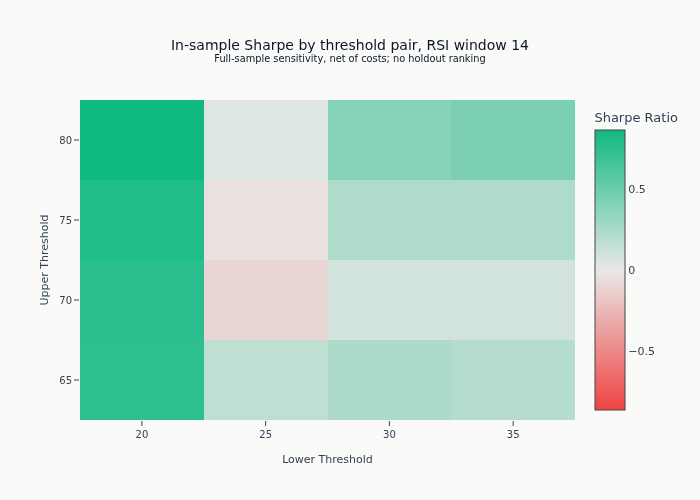

In [30]:
fig = go.Figure(
    data=go.Heatmap(
        x=lower_thresholds,
        y=upper_thresholds,
        z=heatmap_z,
        colorscale=ml4t_diverging(),
        zmid=0,
        colorbar=dict(title="Sharpe Ratio"),
    )
)

fig.update_layout(
    title=(
        f"In-sample Sharpe by threshold pair, RSI window {RSI_WINDOW}"
        "<br><sup>Full-sample sensitivity, net of costs; no holdout ranking</sup>"
    ),
    xaxis_title="Lower Threshold",
    yaxis_title="Upper Threshold",
    height=500,
)
show_plotly_with_alt(
    fig,
    (
        "Heatmap of in-sample Sharpe ratio over the RSI threshold grid, lower threshold on "
        "the horizontal axis and upper threshold on the vertical, one cell per pair, on a "
        f"diverging colour scale centred at zero. The RSI window is held at {RSI_WINDOW} "
        "throughout, so the surface varies in the two thresholds alone. Every cell is scored "
        "on the whole sample with no holdout, which is what makes this a sensitivity surface "
        "rather than a selection procedure."
    ),
)

In [31]:
lower_column = window_results.filter(pl.col("lower") == window_best["lower"])["sharpe"]

display(
    Markdown(
        f"The highest-Sharpe grid row reaches **{best_parameters['sharpe']:.2f}** in sample, versus "
        f"**{baseline_sharpe:.2f}** for the configured baseline. That gap measures full-sample "
        "selection, not forecast improvement: every candidate was ranked after observing the same "
        "return path. NB 12 introduces the Deflated Sharpe Ratio for this multiple-testing problem."
        f"\n\nInside the window-{RSI_WINDOW} surface the peak sits at "
        f"{window_best['lower']}/{window_best['upper']} with a Sharpe of "
        f"{window_best['sharpe']:.2f}, but the whole lower-threshold-{window_best['lower']} column "
        f"spans only {float(lower_column.min()):.2f} to {float(lower_column.max()):.2f} across the "
        "four upper thresholds. The lower threshold is what moves this surface; reading the single "
        "best cell as a choice of upper threshold reads noise."
    )
)

The highest-Sharpe grid row reaches **1.24** in sample, versus **0.09** for the configured baseline. That gap measures full-sample selection, not forecast improvement: every candidate was ranked after observing the same return path. NB 12 introduces the Deflated Sharpe Ratio for this multiple-testing problem.

Inside the window-14 surface the peak sits at 20/80 with a Sharpe of 0.87, but the whole lower-threshold-20 column spans only 0.75 to 0.87 across the four upper thresholds. The lower threshold is what moves this surface; reading the single best cell as a choice of upper threshold reads noise.

## 9. Evaluate with ml4t-diagnostic

`PortfolioAnalysis` recomputes portfolio statistics from the return series. Agreement on total
return and maximum drawdown provides a cross-library accounting check; the remaining rows extend
the report with distribution and benchmark-relative diagnostics.

In [32]:
strategy_returns = portfolio.returns().values
benchmark_returns = bh_portfolio.returns().values

analysis = PortfolioAnalysis(
    returns=strategy_returns,
    benchmark=benchmark_returns,
    dates=portfolio.returns().index,
    periods_per_year=365,  # Crypto trades 365 days
)

metrics = analysis.compute_summary_stats()
assert abs(metrics.total_return - baseline_return) < 1e-10
assert abs(metrics.max_drawdown - strategy_drawdown) < 1e-10

**Selected ml4t-diagnostic portfolio statistics:**

In [33]:
percentage_metrics = [
    "total_return",
    "annual_return",
    "annual_volatility",
    "max_drawdown",
    "var_95",
    "cvar_95",
    "win_rate",
    "avg_win",
    "avg_loss",
    "alpha",
]
metrics_table = (
    metrics.to_dataframe()
    .unpivot(variable_name="metric", value_name="value")
    .filter(~pl.col("metric").is_in(["up_capture", "down_capture"]))
    .with_columns(
        pl.when(pl.col("metric").is_in(percentage_metrics))
        .then((pl.col("value") * 100).round(2))
        .otherwise(pl.col("value").round(3))
        .alias("value"),
        pl.when(pl.col("metric").is_in(percentage_metrics))
        .then(pl.lit("%"))
        .otherwise(pl.lit("unitless"))
        .alias("unit"),
    )
)
metrics_table

metric,value,unit
str,f64,str
"""total_return""",-25.39,"""%"""
"""annual_return""",-7.06,"""%"""
"""annual_volatility""",46.69,"""%"""
"""sharpe_ratio""",0.09,"""unitless"""
"""sortino_ratio""",0.121,"""unitless"""
…,…,…
"""avg_win""",2.37,"""%"""
"""avg_loss""",-2.24,"""%"""
"""alpha""",-29.63,"""%"""


## See Also

**ml4t-backtest Implementation**: See [`04_single_asset_ml4t_backtest`](04_single_asset_ml4t_backtest.ipynb) for the same
strategy implemented with ml4t-backtest's event-driven engine. The main difference
is not capability - VectorBT also supports stops, fills, and risk rules - but
representation: ml4t-backtest expresses strategy logic as a Python class with
explicit state, which mirrors how live trading code is typically structured.

## Key Takeaways

1. **VectorBT API**: `Portfolio.from_signals()` is the core function for signal-based backtests

2. **Signal timing**: Close-derived conditions are shifted to the next UTC-day open

3. **Parameter sensitivity**: Vectorized operations enable fast parameter sweeps, but ranking
   candidates on one sample does not establish out-of-sample improvement

4. **Transaction costs**: Strategy and benchmark use the same fee and slippage convention

5. **Benchmarking**: A same-budget buy-and-hold path separates timing from passive exposure

## Next Steps

- **06_framework_parity**: Compare vectorized and event-driven implementations
- **08_signal_method_comparison**: Compare signal conversion methods